**Imports & Data Loading**

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import scipy.cluster.hierarchy as sch
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer

# Load the data
df = pd.read_csv('marketing_campaign.csv', sep="\t")
print("Tools loaded and Data imported!")

Tools loaded and Data imported!


**Basic Cleaning & Filtering**

In [3]:
# Remove empty rows
df = df.dropna()

# Age and Income Outliers
df['Age'] = 2024 - df['Year_Birth']
df = df[df['Age'] < 90]
df = df[df['Income'] < 600000]

print("Data cleaned of outliers.")

Data cleaned of outliers.


**Advanced Feature Engineering (The Psychology/Media Corner)**

In [4]:
# 1. Total Spending (Rational vs. Emotional)
df['Rational_Spent'] = df['MntFruits'] + df['MntMeatProducts'] + df['MntFishProducts']
df['Emotional_Spent'] = df['MntWines'] + df['MntSweetProducts'] + df['MntGoldProds']
df['Total_Spent'] = df['Rational_Spent'] + df['Emotional_Spent']

# 2. Parental Status
df['Is_Parent'] = (df['Kidhome'] + df['Teenhome'] > 0).astype(int)
df['Total_Minors'] = df['Kidhome'] + df['Teenhome']

# 3. Digital Savvy & Loyalty
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)
df['Days_As_Customer'] = (pd.Timestamp('2024-01-01') - df['Dt_Customer']).dt.days
df['Digital_Ratio'] = (df['NumWebPurchases'] + df['NumCatalogPurchases']) / (df['NumStorePurchases'] + 1)

print("'Human Angle' features created.")

'Human Angle' features created.


**Scaling & PCA (Dimensionality Reduction)**

In [5]:
# Select only numerical columns for the AI
numeric_cols = df.select_dtypes(include=[np.number]).columns
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[numeric_cols])

# PCA - Reducing 29 columns into 3 "Main Components"
pca = PCA(n_components=3)
pca_results = pca.fit_transform(scaled_data)
df_pca = pd.DataFrame(pca_results, columns=['PC1', 'PC2', 'PC3'])

print("Math done: Data scaled and reduced to 3 dimensions.")

Math done: Data scaled and reduced to 3 dimensions.


**The Evidence (Elbow Method & Silhouette Score)**

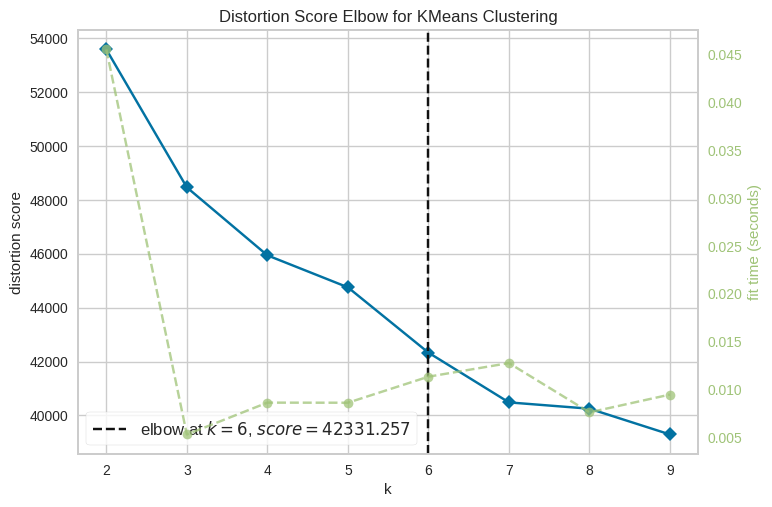

Silhouette Score: 0.187


In [6]:
# Finding the optimal 'K'
visualizer = KElbowVisualizer(KMeans(random_state=42), k=(2,10))
visualizer.fit(scaled_data)
visualizer.show()

# Quick math check
kmeans_test = KMeans(n_clusters=4, random_state=42)
labels_test = kmeans_test.fit_predict(scaled_data)
print(f"Silhouette Score: {silhouette_score(scaled_data, labels_test):.3f}")

**Applying KMeans & Persona Mapping**

In [7]:
# Apply final clustering
kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_data)

# Create Persona Names
persona_map = {
    0: "The Elite High-Spenders",
    1: "The Budget Families",
    2: "The Tech-Savvy Youth",
    3: "The Occasional Shoppers"
}
df['Persona'] = df['Cluster'].map(persona_map)

print("AI has assigned personas to all customers.")

AI has assigned personas to all customers.


**The Dendrogram (Hierarchical Comparison)**

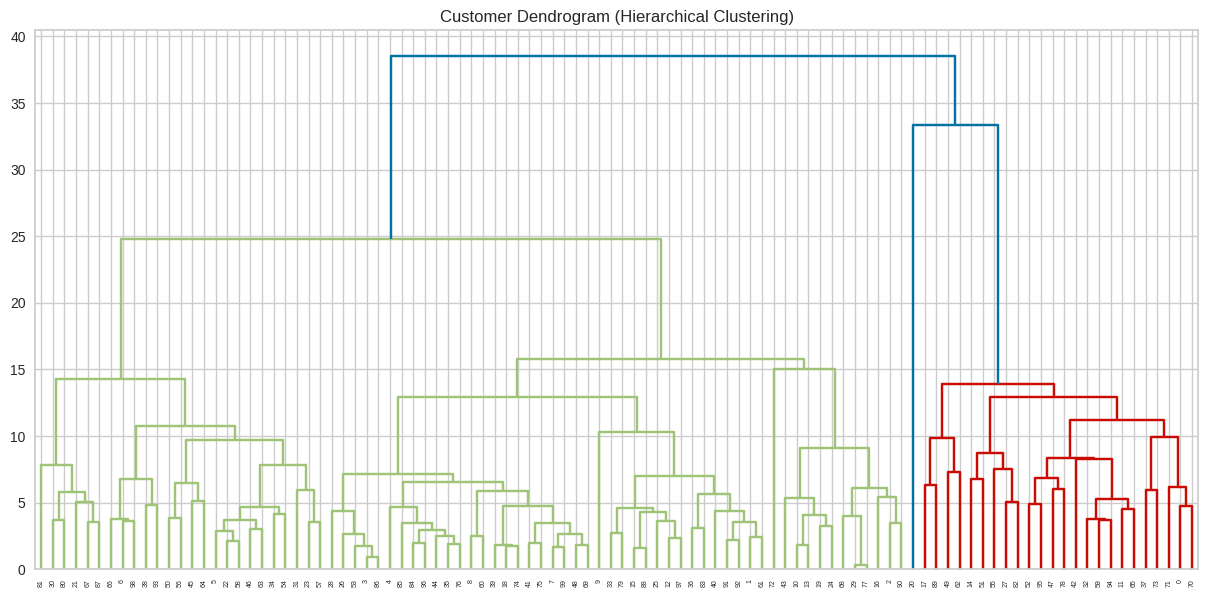

In [8]:
plt.figure(figsize=(15, 7))
plt.title("Customer Dendrogram (Hierarchical Clustering)")
dend = sch.dendrogram(sch.linkage(scaled_data[:100], method='ward'))
plt.show()

**The Income vs Spent Logic**

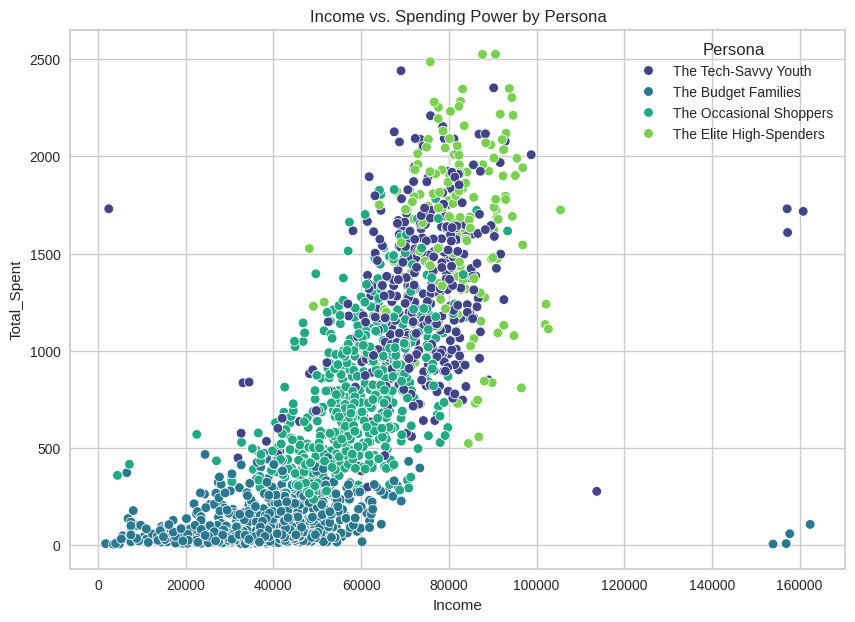

In [9]:
plt.figure(figsize=(10,7))
sns.scatterplot(x=df['Income'], y=df['Total_Spent'], hue=df['Persona'], palette='viridis')
plt.title('Income vs. Spending Power by Persona')
plt.show()

**The 3D Interactive Masterpiece**

In [10]:
fig = px.scatter_3d(df, x=df_pca['PC1'], y=df_pca['PC2'], z=df_pca['PC3'],
                    color='Persona', title="Final 3D Persona Map",
                    labels={'PC1': 'Spending', 'PC2': 'Digital Habits', 'PC3': 'Demographics'})
fig.show()